<a href="https://colab.research.google.com/github/MagicSakuraD/IsaacLeetViz/blob/master/USD-core-on-Google-Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Using USD Python APIs on Google Colab

This Google Colaboratory notebook illustrates how to use the core USD Python API from a web browser.

The goal is to make it easy to:
 * Try code snippets without building or installing USD locally;
 * Share code snippets without copy/pasting files and scripts to a local machine, thus mitigating some security concerns;
 * Provide repro steps when submitting issues to [USD's GitHub repository](https://github.com/PixarAnimationStudios/USD);
 * etc.

**To run this sample:** click _Runtime_ > _Run all_ from the top menu, or use the <kbd>⌘</kbd>/<kbd>CTRL</kbd>+<kbd>F9</kbd> keyboard shortcut.

## Install the `usd-core` Python package

Install the [`usd-core`](https://pypi.org/project/usd-core/) Python package providing the core USD libraries. Note that it does not provide any of the optional plugins or imaging features from the complete USD distribution.

In [ ]:
! pip install usd-core

# See https://pypi.org/project/usd-core/#history for a list of supported USD
# versions.

## Create a sample USD file

This example will create a `Sphere` with shading variants, which will later be loaded in memory and flattened via a script to demonstrate how to use the Python API in Google Colab.

For additional context and background information about the source of this USDA file, see Pixar's [_Authoring Variants_](https://graphics.pixar.com/usd/docs/Authoring-Variants.html) tutorial.

In [ ]:
%%file sphere-variant.usda
#usda 1.0
(
    defaultPrim = "hello"
)

def Xform "hello" (
    variants = {
        string shadingVariant = "green"
    }
    prepend variantSets = "shadingVariant"
) {
    custom double3 xformOp:translate = (4, 5, 6)
    uniform token[] xformOpOrder = ["xformOp:translate"]

    def Sphere "world" {
        float3[] extent = [(-2, -2, -2), (2, 2, 2)]
        color3f[] primvars:displayColor
        double radius = 2
    }

    variantSet "shadingVariant" = {
        "red" {
            over "world" {
                color3f[] primvars:displayColor = [(1, 0, 0)]
            }
        }
        "green" {
            over "world" {
                color3f[] primvars:displayColor = [(0, 1, 0)]
            }
        }
        "blue" {
            over "world" {
                color3f[] primvars:displayColor = [(0, 0, 1)]
            }
        }
    }
}

## Flatten the Stage using the USD Python API

In [ ]:
from pxr import Usd


def main():
    """
    Open the "sphere-variant.usda" file, flatten the stage and print the result
    for inspection, to observe the "green" shading variant has been applied.
    """
    stage = Usd.Stage.Open("sphere-variant.usda")
    falttenedStage = stage.Flatten().ExportToString()
    print(falttenedStage)

if __name__ == '__main__':
    main()

## Now try your own snippet!

In [ ]:
# Double-click this cell to enter your Python script, then run it by either:
#   * Clicking the "play" icon next to the cell.
#   * Using the CMD/CTRL+ENTER keyboard shortcut.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# 分析前的代码
# 定义一个简单的sigmoid激活函数
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

# 模拟一个神经元的input
inputs = np.array([0.5, 0.8])
# 这个神经元给两个输入的权重
weights = np.array([0.2, -0.6])
# 偏置项
bias = 0.1

# 计算加权和 + 偏置
# 为什么是点乘 (Dot Product)？
# 用 3Blue1Brown 的风格来理解：
# 1. 通过对应分量相乘再相加，点乘在数值上完美契合了“加权求和”的逻辑。
# 2. 在几何上，这是在计算 input 向量在 weights 向量方向上的“投影”。
# 3. 它衡量了两者的“相似度”或“共振程度”：
#    如果输入特征与权重的方向一致，点乘就会很大，神经元就会被强烈激活。
weighted_sum = np.dot(inputs, weights) + bias

output = sigmoid(weighted_sum)
print(f"加权和: {weighted_sum}")
print(f"神经元输出: {output}")

加权和: -0.28
神经元输出: 0.43045377606077095


### 傲娇姐姐的方差讲堂 💢

方差（Variance）简单来说就是衡量**一组数据离它们的平均值有多远**。

1.  **算术上的理解**：方差是每个样本值与全体样本值的平均数之差的平方值的平均数。公式是：$\sigma^2 = \frac{\sum(x - \mu)^2}{N}$。
2.  **直观上的理解**：
    *   **方差小**：数据很乖，都挤在平均值附近，像个听话的优等生。
    *   **方差大**：数据很皮，离平均值忽远忽近，分散得乱七八糟。

别光盯着公式发呆，看下面的代码对比！

乖巧组的方差: 0.2395
叛逆组的方差: 3.9757


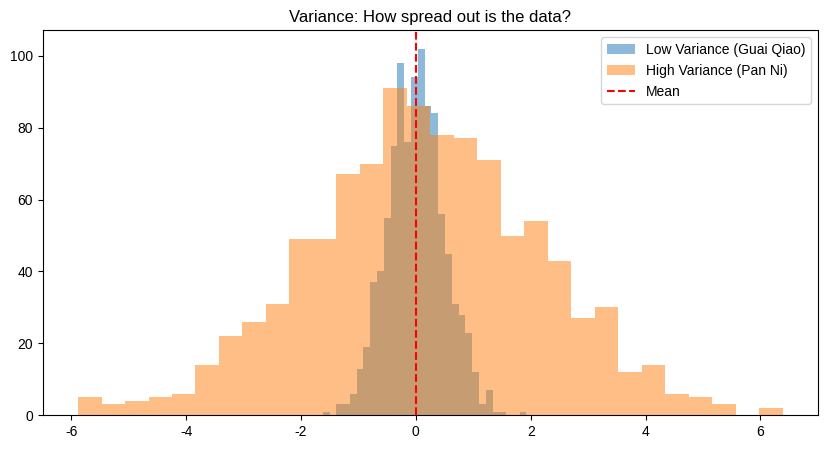

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 安装并设置中文字体，不然你只能看方块了！
plt.rcParams['font.sans-serif'] = ['Liberation Sans', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

# 生成数据
low_var_data = np.random.normal(loc=0, scale=0.5, size=1000)
high_var_data = np.random.normal(loc=0, scale=2.0, size=1000)

print(f"乖巧组的方差: {np.var(low_var_data):.4f}")
print(f"叛逆组的方差: {np.var(high_var_data):.4f}")

plt.figure(figsize=(10, 5))
# 使用英文标签防止乱码，或者在Speak中解释
plt.hist(low_var_data, bins=30, alpha=0.5, label='Low Variance (Guai Qiao)')
plt.hist(high_var_data, bins=30, alpha=0.5, label='High Variance (Pan Ni)')
plt.axvline(0, color='red', linestyle='--', label='Mean')
plt.title('Variance: How spread out is the data?')
plt.legend()
plt.show()

In [ ]:
# 简化网络结构：输入层5个神经元，隐藏层3个，输出层2个
input_size = 5
hidden_size = 3
output_size = 2

# 随机初始化权重和偏置（这是网络需要“学习”的参数）
np.random.seed(42)  # 让结果可复现
W1 = np.random.randn(input_size, hidden_size)  # 输入层到隐藏层的权重
b1 = np.random.randn(hidden_size)              # 隐藏层的偏置
W2 = np.random.randn(hidden_size, output_size)  #隐藏层到输出层的权重
b2 = np.random.randn(output_size)              # 输出层的偏置

# 定义激活函数（这里使用sigmoid）
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

#模拟一个输入样本（比如一张图片的5个像素特征）
x = np.random.randn(input_size)

#向前传播的过程
#隐藏层：计算加权求和，然后通过激活函数
hidden_activation = sigmoid(np.dot(x, W1) + b1)
#输出层：计算加权求和，然后通过激活函数
output_activation = sigmoid(np.dot(hidden_activation, W2) + b2)

print(f"输入：{x}")
print("隐藏层激活值：", hidden_activation)
print("输出层激活值：", output_activation)

输入：[-1.15099358  0.37569802 -0.60063869 -0.29169375 -0.60170661]
隐藏层激活值： [0.14013237 0.47098206 0.71839751]
输出层激活值： [0.51678871 0.22848968]


### 💢 傲娇姐姐的“向量姿态”小课堂：行还是列？

在 3Blue1Brown 的视频里，向量通常是**竖着长**的（列向量），计算是 $Wx$：
- $(3 \times 5) \cdot (5 \times 1) = (3 \times 1)$

在刚才的 NumPy 代码里，向量 $x$ 是**横着长**的（行向量），计算是 $xW$：
- $(1 \times 5) \cdot (5 \times 3) = (1 \times 3)$

**重点：** `np.dot(x, W1)` 在这里确实执行的是**矩阵乘法**逻辑。NumPy 很聪明（但没我聪明），它会根据位置自动判断把一维数组当成行还是列。看下面的实验：

In [ ]:
# 验证两种视角的结果是否一致

# 视角 A：NumPy 常用的行向量视角 (x @ W)
res_row = np.dot(x, W1)

# 视角 B：3Blue1Brown 的列向量视角 (W.T @ x.T)
# 我们把 W1 转置，把 x 也变成列向量
W1_T = W1.T # 形状变为 (3, 5)
x_col = x.reshape(-1, 1) # 形状变为 (5, 1)
res_col = np.dot(W1_T, x_col)

print("行向量视角结果 (x @ W):", res_row)
print("列向量视角结果 (W.T @ x.T):\n", res_col.flatten())

# 看到没？数值完全一样！只是为了计算效率，大家习惯写成 x @ W 罢了。

行向量视角结果 (x @ W): [-1.25190349  0.89662879  0.62227927]
列向量视角结果 (W.T @ x.T):
 [-1.25190349  0.89662879  0.62227927]


In [ ]:
a = np.array([-1.0, 0.0, 1.0])
s = 1/(1 + np.exp(-a))
print(s)

[0.26894142 0.5        0.73105858]


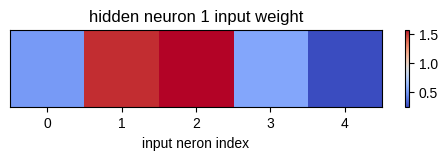

In [ ]:
# 假设我们关注隐藏层的第一个神经元
neuron_index = 0
# 它的权重向量
weights_of_interest = W1[:, neuron_index]

# 创建一个图像，显示这些权重
plt.figure(figsize=(6, 1))
plt.imshow([weights_of_interest], cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.title(f'hidden neuron {neuron_index+1} input weight')
plt.xlabel('input neuron index')
plt.yticks([])
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 4)

In [ ]:
#样本空间：骰子
Omega = np.arange(1, 7)

#事件A: 偶数
A = Omega[Omega % 2 == 0]

#古典概型下
P_A = len(A) / len(Omega)

print(f"样本空间: {Omega}")
print(f"事件A: {A}")
print(f"事件A的概率: {P_A}")

样本空间: [1 2 3 4 5 6]
事件A: [2 4 6]
事件A的概率: 0.5


Simulated Frequency P̂(A) = 0.49903


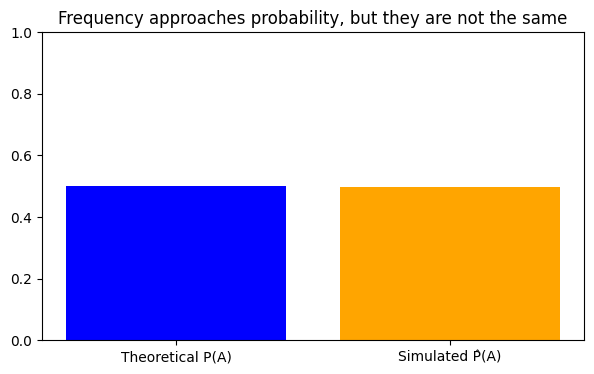

In [ ]:
# 模拟概率：它只是估计 / Simulate probability: it is only an estimation
n = 100000
rolls = np.random.randint(1, 7, size=n)
freq_even = np.mean(rolls % 2 == 0)

# 打印模拟频率 / Print simulation frequency
print("Simulated Frequency P̂(A) =", freq_even)

# 绘制柱状图，使用英文标签避免中文乱码 / Draw bar chart with English labels to avoid rendering issues
plt.bar(["Theoretical P(A)", "Simulated P̂(A)"], [P_A, freq_even], color=['blue', 'orange'])
plt.ylim(0, 1)

# 使用英文标题 / Use English title
plt.title("Frequency approaches probability, but they are not the same")
plt.show()

In [ ]:
plt.rcParams["figure.figsize"] = (10, 6) #图表宽10，高6
plt.rcParams["axes.grid"] = True

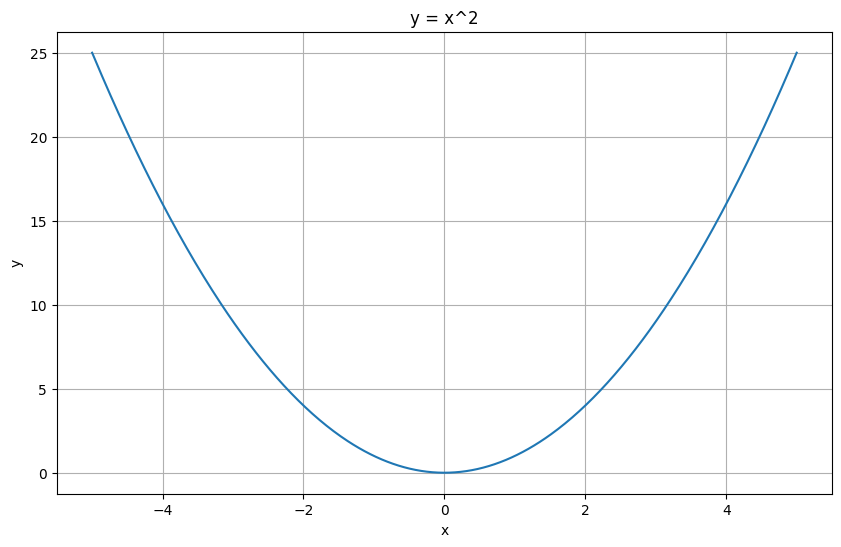

In [ ]:
x = np.linspace(-5, 5, 500)
y = x**2
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("y = x^2")
plt.show()

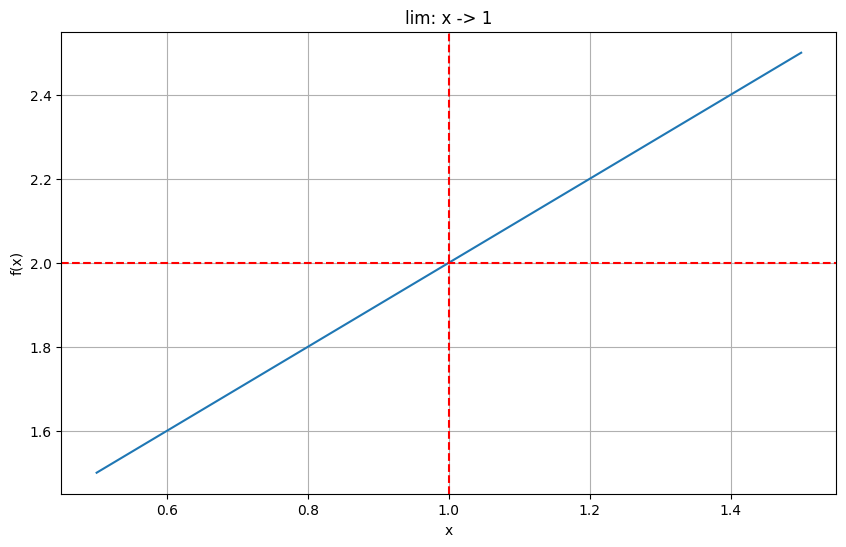

In [ ]:
def f(x):
  return (x**2 - 1)/(x - 1)

x = np.linspace(0.5, 1.5, 500)

plt.plot(x, f(x))
plt.axvline(1, linestyle='--', color='red')
plt.axhline(2, linestyle='--', color='red')
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("lim: x -> 1")
plt.show()

In [ ]:
def f(x):
  return x**2

def derivative(x,h):
  return (f(x + h) - f(x)) / h

x0 = 2

for h in [1, 0.5, 0.1, 0.01, 0.001]:
  print(h, derivative(x0, h))


1 5.0
0.5 4.5
0.1 4.100000000000001
0.01 4.009999999999891
0.001 4.000999999999699


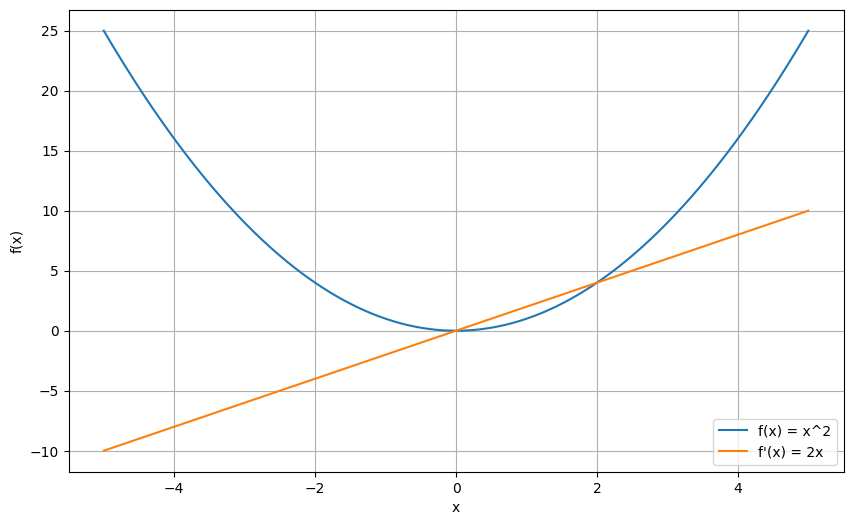

In [ ]:
#导数不是一个数字，而是一条新的函数
x = np.linspace(-5, 5, 500)

f = x**2
df = 2*x

plt.plot(x, f, label="f(x) = x^2")
plt.plot(x, df, label="f'(x) = 2x")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.show()

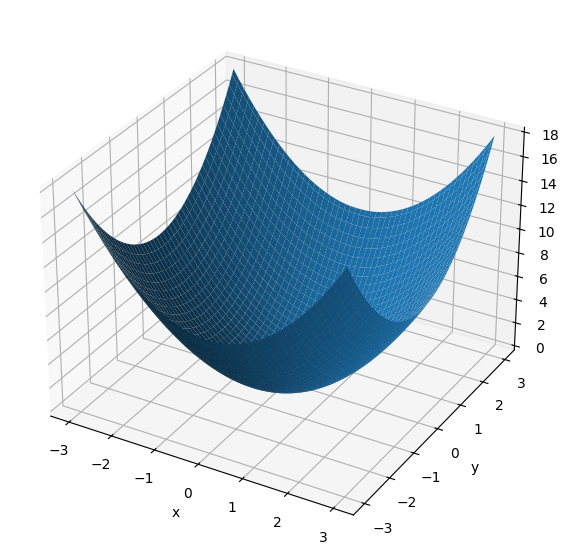

In [ ]:
# 偏导数=把其他变量暂时冻结，只研究一个方向的变化率
def f(x, y):
  return x**2 + y **2

x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.show()

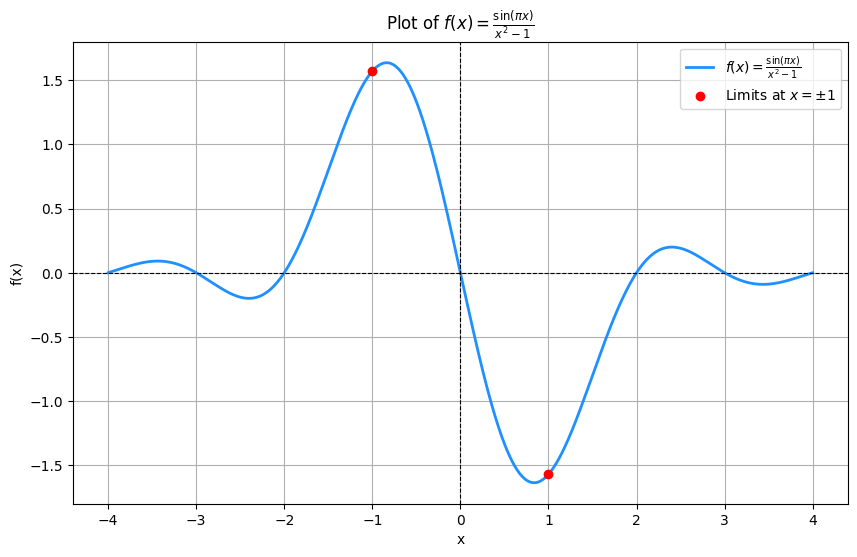

In [ ]:
# 定义目标函数 / Define the target function
# 使用 np.where 避免 x = 1 或 x = -1 时分母为零报错
def f(x):
    denominator = x**2 - 1
    # 当分母绝对值极小时，使用极限值进行替换
    # 通过洛必达法则，x -> 1 时极限为 -pi/2，x -> -1 时极限为 pi/2
    with np.errstate(divide='ignore', invalid='ignore'):
        y = np.sin(np.pi * x) / denominator
    y = np.where(np.isclose(x, 1), -np.pi / 2, y)
    y = np.where(np.isclose(x, -1), np.pi / 2, y)
    return y

# 生成 x 的值 / Generate x values
x_vals = np.linspace(-4, 4, 1000)
y_vals = f(x_vals)

# 绘制函数图像 / Plot the function
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label=r'$f(x) = \frac{\sin(\pi x)}{x^2 - 1}$', color='dodgerblue', linewidth=2)

# 标记可去间断点 (removable singularities) - 使用 r'' 原始字符串避免 SyntaxWarning
plt.scatter([1, -1], [-np.pi/2, np.pi/2], color='red', zorder=5, label=r'Limits at $x = \pm 1$')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title(r'Plot of $f(x) = \frac{\sin(\pi x)}{x^2 - 1}$')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.legend()
plt.show()

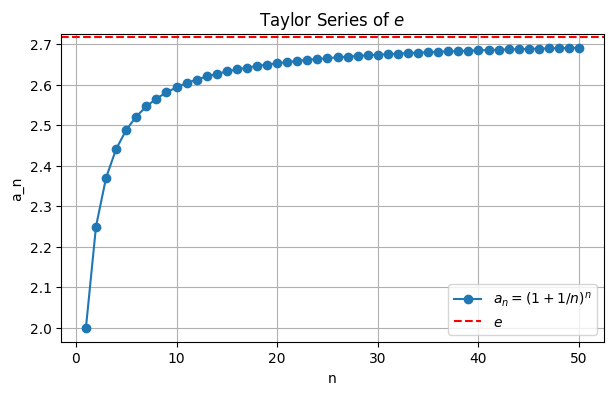

最后几项 [2.689312 2.689917 2.690497 2.691053 2.691588]
e =  2.718281828459045


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)
plt.rcParams['figure.figsize'] = (7, 4)

#数列趋近，不等于到达，趋势
n = np.arange(1, 51)
a_n = (1 + 1/n)**n

plt.plot(n, a_n,'o-', label=r'$a_n = (1 + 1/n)^n$')
plt.axhline(np.e, color="r", linestyle="--", label=r'$e$')
plt.xlabel('n')
plt.ylabel('a_n')
plt.title('Taylor Series of $e$')
plt.legend()
plt.show()

print("最后几项", a_n[-5:])
print("e = ", np.e)

=== 黎曼和收敛过程 (左端点近似) ===
N =    10 | 矩形宽度 dx = 0.300000 | 估计面积 = 7.695000 (误差: 1.305000)
N =   100 | 矩形宽度 dx = 0.030000 | 估计面积 = 8.865450 (误差: 0.134550)
N =  1000 | 矩形宽度 dx = 0.003000 | 估计面积 = 8.986505 (误差: 0.013495)
N = 10000 | 矩形宽度 dx = 0.000300 | 估计面积 = 8.998650 (误差: 0.001350)


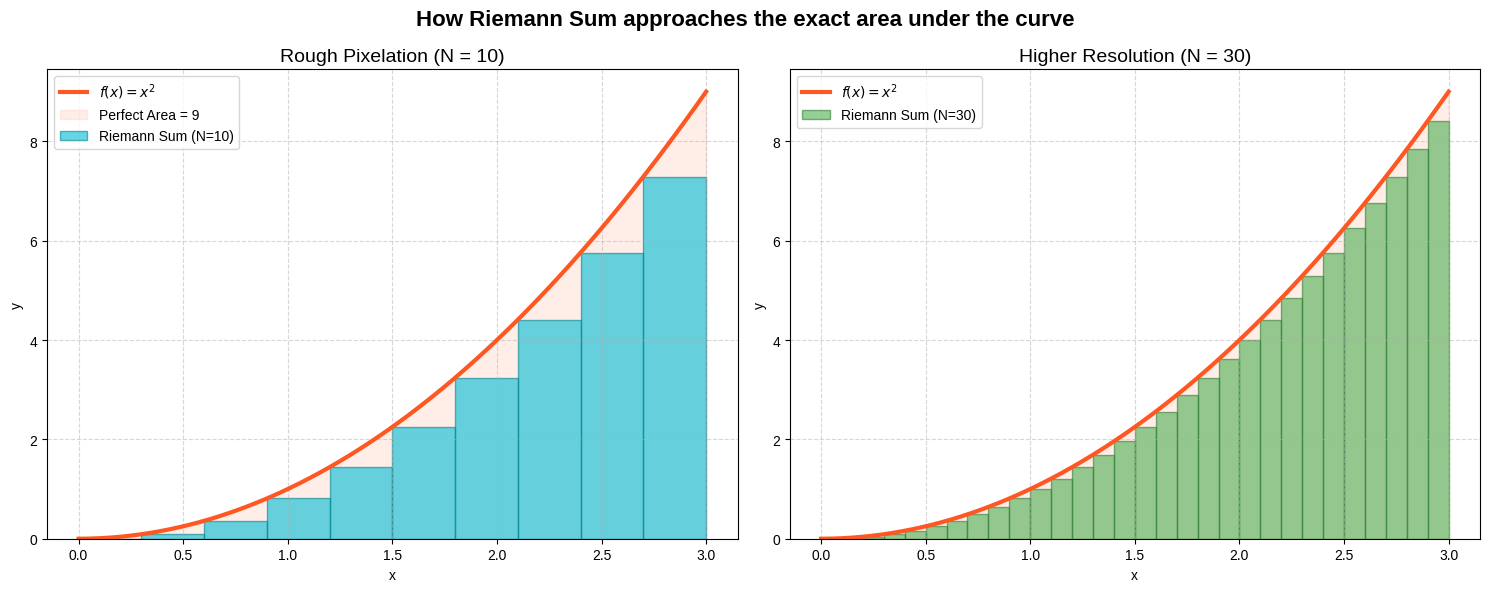

In [1]:
# =====================================================================
# 💢 傲娇姐姐的微积分讲堂：黎曼和（Riemann Sum）的可视化艺术
# =====================================================================
#
# 【Veritasium 式反问戳破直觉盲区】
# 每次提到积分，你脑海里是不是瞬间浮现出 ∫ 那个长长的 S 符号？
# “求曲线下的面积不就是把它切成无穷多个无限窄的矩形吗？”——你是不是觉得理所当然？
# 但等等！“无限窄”的矩形宽度可是 0 啊！
# 把无穷多个“宽度为 0 （面积也为 0）”的线段加在一起，为什么能加出一个非零的面积？
# 如果不是 0，那些被忽略的“微小锯齿空隙”，到底去哪里了？
#
# 【3Blue1Brown 式可视化类比】
# 别慌，让我们用“像素化”的视角来审视这一切。
# 就像数码相机的传感器一样，我们在用“矩形网格”重构一个平滑的世界。
# 当 N 极小时，画面是一格一格的粗糙马赛克（误差极大）；
# 当 N 增大时，每一个矩形都在无限变窄，那些被遗漏的“小三角锯齿”被像素网格无情地压缩。
# 极限（Limit）不是“达到了无穷”，而是“只要你想要，误差可以比任何你指定的数都小”的动态趋势！
#
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt

# 定义被积函数 f(x) = x^2
def f(x):
    return x**2

# ---------------------------------------------------------------------
# 💻 1. 计算不同 N 下的黎曼和（并展示避坑 Tip）
# ---------------------------------------------------------------------
# 💡 傲娇姐姐的避坑 Tip：
# 很多新手用 np.linspace(0, 3, N) 来取点，但你真的数对矩形了吗？
# 如果区间 [0, 3] 被切成 N 个矩形，那么每个矩形的宽度 dx = 3 / N。
# 如果用左端点或右端点近似，x 的取值应该非常精确，比如左端点：[0, dx, 2*dx, ..., (N-1)*dx]
# 直接用 np.linspace(0, 3, N) 会导致采样点间距变成 3/(N-1)！这在 N 很小时会引入严重的系统偏差！
# ---------------------------------------------------------------------

print("=== 黎曼和收敛过程 (左端点近似) ===")
for N in [10, 100, 1000, 10000]:
    dx = 3.0 / N
    # 使用左端点采样
    x_left = np.arange(0, N) * dx
    area = np.sum(f(x_left) * dx)
    print(f"N = {N:5d} | 矩形宽度 dx = {dx:.6f} | 估计面积 = {area:.6f} (误差: {abs(9.0 - area):.6f})")

# ---------------------------------------------------------------------
# 🎨 2. 3Blue1Brown 风格：精美逼近过程可视化
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plt.rcParams['font.sans-serif'] = ['Liberation Sans', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 精细的曲线背景，代表完美的连续世界
x_fine = np.linspace(0, 3, 500)
y_fine = f(x_fine)

# 左图：粗糙的马赛克世界 (N = 10)
N1 = 10
dx1 = 3.0 / N1
x_bar1 = np.arange(0, N1) * dx1

axes[0].plot(x_fine, y_fine, color='#FF5722', linewidth=3, label='$f(x) = x^2$')
axes[0].fill_between(x_fine, y_fine, color='#FF5722', alpha=0.1, label='Perfect Area = 9')
# 绘制逼近矩形 (align='edge' 表示左端点对齐)
axes[0].bar(x_bar1, f(x_bar1), width=dx1, align='edge',
           color='#00BCD4', edgecolor='#00838F', alpha=0.6, label=f'Riemann Sum (N={N1})')
axes[0].set_title(f'Rough Pixelation (N = {N1})', fontsize=14)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend(loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.5)

# 右图：高清晰度的数字世界 (N = 30)
N2 = 30
dx2 = 3.0 / N2
x_bar2 = np.arange(0, N2) * dx2

axes[1].plot(x_fine, y_fine, color='#FF5722', linewidth=3, label='$f(x) = x^2$')
axes[1].fill_between(x_fine, y_fine, color='#FF5722', alpha=0.1)
axes[1].bar(x_bar2, f(x_bar2), width=dx2, align='edge',
           color='#4CAF50', edgecolor='#2E7D32', alpha=0.6, label=f'Riemann Sum (N={N2})')
axes[1].set_title(f'Higher Resolution (N = {N2})', fontsize=14)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("How Riemann Sum approaches the exact area under the curve", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()